In [1]:
# ── 5.0  IMPORTS ─────────────────────────────────────────────
import os, json, time, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [2]:
# ── 5.1  REPRODUCIBILITY ──────────────────────────────────────
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

Device: cuda


In [11]:
# ── 5.3  HYPERPARAMETERS ──────────────────────────────────────
MODEL_NAME   = 'bert-base-uncased'
MAX_LEN      = 128
BATCH_SIZE   = 32
LR           = 2e-5
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01
EPOCHS       = 10
PATIENCE     = 2
NUM_CLASSES  = 3
NUM_WORKERS  = 0   

# ── 5.4  LOAD DATA & CLASS WEIGHTS ───────────────────────────
df_train = pd.read_csv('../data/train.csv')
df_val   = pd.read_csv('../data/val.csv')
df_test  = pd.read_csv('../data/test.csv')

with open('../data/class_weights.json') as f:
    cw_dict = {int(k): v for k, v in json.load(f).items()}

cw_tensor = torch.tensor([cw_dict[i] for i in range(3)], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']


In [12]:
# ── 5.5  TOKENISER ────────────────────────────────────────────
print(f"Loading tokeniser: {MODEL_NAME}")
tokeniser = BertTokenizerFast.from_pretrained(MODEL_NAME)

# DESIGN DECISION — WordPiece tokenisation example
example = "the HDMI port stopped working after two weeks"
tokens = tokeniser.tokenize(example)
print(f"\nWordPiece tokenisation example:")
print(f"  Input : '{example}'")
print(f"  Tokens: {tokens}")
print("  Note: electronics terms decomposed into subwords (e.g. 'HD'+'##MI')")
print("  Unlike BiLSTM (vocab=15k), out-of-vocabulary terms handled gracefully.")

Loading tokeniser: bert-base-uncased

WordPiece tokenisation example:
  Input : 'the HDMI port stopped working after two weeks'
  Tokens: ['the', 'hd', '##mi', 'port', 'stopped', 'working', 'after', 'two', 'weeks']
  Note: electronics terms decomposed into subwords (e.g. 'HD'+'##MI')
  Unlike BiLSTM (vocab=15k), out-of-vocabulary terms handled gracefully.


In [13]:
# ── 5.6  PYTORCH DATASET ──────────────────────────────────────
class TransformerDataset(Dataset):
    """
    Tokenises all texts once in __init__ — O(1) at __getitem__.
    Stores input_ids, attention_mask, token_type_ids as pre-computed tensors.
    use_tt=True for BERT (requires token_type_ids from NSP pre-training).
    use_tt=False for RoBERTa (NSP removed — passing token_type_ids raises TypeError).
    """
    def __init__(self, df, tokeniser, max_len, use_tt=True):
        texts  = df['combined_text'].fillna('').astype(str).tolist()
        labels = df['label'].tolist()

        encoding = tokeniser(
            texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
            return_token_type_ids=use_tt
        )
        self.input_ids      = encoding['input_ids']
        self.attention_mask = encoding['attention_mask']
        self.token_type_ids = encoding.get('token_type_ids', None)
        self.labels         = torch.tensor(labels, dtype=torch.long)
        self.use_tt         = use_tt

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx]
        }
        if self.use_tt and self.token_type_ids is not None:
            item['token_type_ids'] = self.token_type_ids[idx]
        return item

print(f"\nTokenising datasets (max_length={MAX_LEN})...")
train_ds = TransformerDataset(df_train, tokeniser, MAX_LEN, use_tt=True)
val_ds   = TransformerDataset(df_val,   tokeniser, MAX_LEN, use_tt=True)
test_ds  = TransformerDataset(df_test,  tokeniser, MAX_LEN, use_tt=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print("Datasets tokenised and loaded.")




Tokenising datasets (max_length=128)...
Datasets tokenised and loaded.


In [14]:
# ── 5.7  MODEL ────────────────────────────────────────────────
print(f"\nLoading {MODEL_NAME}...")
bert_model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
).to(DEVICE)

n_params = sum(p.numel() for p in bert_model.parameters())
n_train  = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Total parameters   : {n_params:,}")
print(f"Trainable params   : {n_train:,}")



Loading bert-base-uncased...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters   : 109,484,547
Trainable params   : 109,484,547


In [15]:
# ── 5.8  OPTIMISER — PARAMETER GROUPS ────────────────────────
# DESIGN DECISION: Bias and LayerNorm.weight excluded from weight decay.
# Applying L2 regularisation to normalisation parameters is theoretically
# unjustified — these calibrate scale rather than representational capacity.
# Standard BERT recipe (Devlin et al. 2019).

no_decay = ['bias', 'LayerNorm.weight']
param_groups = [
    {'params': [p for n, p in bert_model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in bert_model.named_parameters()
                if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0}
]
optimizer = AdamW(param_groups, lr=LR, eps=1e-8)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
print(f"\nAdamW: lr={LR}, weight_decay={WEIGHT_DECAY} (non-bias/LN only)")
print(f"Scheduler: linear warmup ({warmup_steps} steps) → linear decay")
print(f"Total steps: {total_steps}, Warmup: {warmup_steps} ({WARMUP_RATIO*100:.0f}%)")



AdamW: lr=2e-05, weight_decay=0.01 (non-bias/LN only)
Scheduler: linear warmup (250 steps) → linear decay
Total steps: 2500, Warmup: 250 (10%)


In [16]:
# ── 5.9  AMP ──────────────────────────────────────────────────
def make_scaler():
    try: return torch.amp.GradScaler('cuda')
    except: return torch.cuda.amp.GradScaler()
def amp_autocast():
    try: return torch.amp.autocast('cuda')
    except: return torch.cuda.amp.autocast()

scaler = make_scaler() if DEVICE.type == 'cuda' else None



In [17]:
# ── 5.10  TRAINING LOOP ──────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)
        tt_ids    = batch.get('token_type_ids')
        if tt_ids is not None: tt_ids = tt_ids.to(DEVICE)

        optimizer.zero_grad()
        if scaler:
            with amp_autocast():
                out = model(input_ids=input_ids, attention_mask=attn_mask,
                            token_type_ids=tt_ids)
                loss = criterion(out.logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            out  = model(input_ids=input_ids, attention_mask=attn_mask,
                         token_type_ids=tt_ids)
            loss = criterion(out.logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()
        total_loss += loss.item()
        all_preds.extend(out.logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss/len(loader), f1_score(all_labels, all_preds, average='macro', zero_division=0)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels, all_proba = 0.0, [], [], []
    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)
        tt_ids    = batch.get('token_type_ids')
        if tt_ids is not None: tt_ids = tt_ids.to(DEVICE)

        out  = model(input_ids=input_ids, attention_mask=attn_mask,
                     token_type_ids=tt_ids)
        loss = criterion(out.logits, labels)
        total_loss += loss.item()
        proba = torch.softmax(out.logits, 1).cpu().numpy()
        all_preds.extend(out.logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_proba.extend(proba)

    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss/len(loader), macro_f1, np.array(all_preds), np.array(all_labels), np.array(all_proba)



In [18]:
# ── 5.11  TRAIN ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("TRAINING BERT")
print("=" * 60)

best_val_f1, patience_ctr = -1.0, 0
history = {'train_loss':[], 'train_f1':[], 'val_loss':[], 'val_f1':[]}
t_start = time.time()

for epoch in range(1, EPOCHS+1):
    t_ep = time.time()
    tr_loss, tr_f1 = train_epoch(bert_model, train_loader, optimizer, scheduler, scaler)
    vl_loss, vl_f1, _, _, _ = evaluate(bert_model, val_loader)
    history['train_loss'].append(tr_loss); history['train_f1'].append(tr_f1)
    history['val_loss'].append(vl_loss);   history['val_f1'].append(vl_f1)

    flag = ''
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        bert_model.save_pretrained('../models/bert_best')
        tokeniser.save_pretrained('../models/bert_best')
        patience_ctr = 0; flag = '  ← best saved'
    else:
        patience_ctr += 1

    print(f"Epoch {epoch}/{EPOCHS} | Train loss={tr_loss:.4f} F1={tr_f1:.4f} | "
          f"Val loss={vl_loss:.4f} F1={vl_f1:.4f} | {time.time()-t_ep:.1f}s{flag}")
    if patience_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nTotal training time: {time.time()-t_start:.1f}s")
print(f"Best validation Macro F1: {best_val_f1:.4f}")



TRAINING BERT
Epoch 1/10 | Train loss=0.8658 F1=0.5497 | Val loss=0.6439 F1=0.7323 | 49.0s  ← best saved
Epoch 2/10 | Train loss=0.5614 F1=0.7089 | Val loss=0.6073 F1=0.7214 | 47.8s
Epoch 3/10 | Train loss=0.3983 F1=0.7976 | Val loss=0.7113 F1=0.7370 | 48.5s  ← best saved
Epoch 4/10 | Train loss=0.2596 F1=0.8778 | Val loss=0.9074 F1=0.7253 | 47.6s
Epoch 5/10 | Train loss=0.1613 F1=0.9282 | Val loss=1.3372 F1=0.7357 | 47.6s
Early stopping at epoch 5

Total training time: 240.5s
Best validation Macro F1: 0.7370


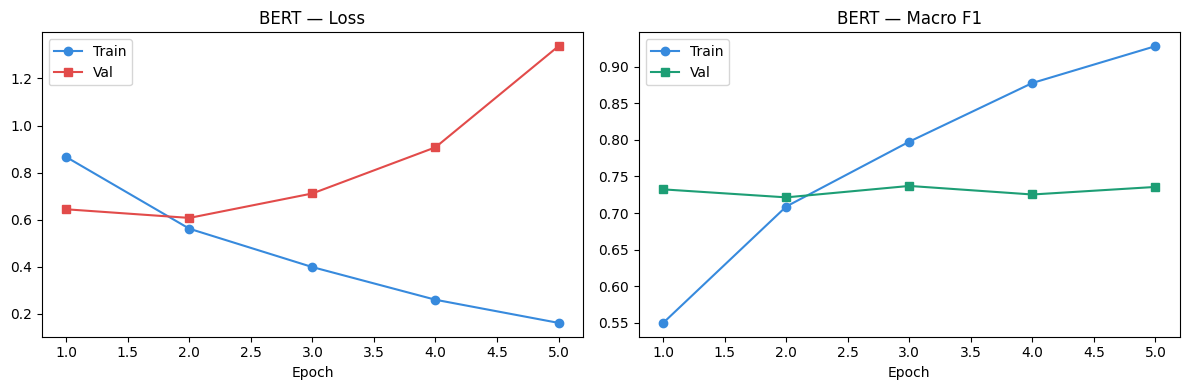

In [19]:
# ── 5.12  TRAINING CURVES ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['train_loss'])+1)
axes[0].plot(ep, history['train_loss'], 'o-', color='#378ADD', label='Train')
axes[0].plot(ep, history['val_loss'],   's-', color='#E24B4A', label='Val')
axes[0].set_title('BERT — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(ep, history['train_f1'], 'o-', color='#378ADD', label='Train')
axes[1].plot(ep, history['val_f1'],   's-', color='#1D9E75', label='Val')
axes[1].set_title('BERT — Macro F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('../results/05_bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# ── 5.13  LOAD BEST & TEST EVALUATION ────────────────────────
bert_model = BertForSequenceClassification.from_pretrained('../models/bert_best').to(DEVICE)
_, _, y_pred, y_test_arr, y_proba = evaluate(bert_model, test_loader)

test_macro_f1 = f1_score(y_test_arr, y_pred, average='macro')
test_acc      = accuracy_score(y_test_arr, y_pred)
test_auc      = roc_auc_score(label_binarize(y_test_arr, classes=[0,1,2]),
                               y_proba, multi_class='ovr', average='macro')

print("\n" + "=" * 60)
print("TEST SET EVALUATION — BERT")
print("=" * 60)
print(f"\n  Macro F1  : {test_macro_f1:.4f}  ← PRIMARY METRIC")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  ROC-AUC   : {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_arr, y_pred, target_names=CLASS_NAMES))



TEST SET EVALUATION — BERT

  Macro F1  : 0.7524  ← PRIMARY METRIC
  Accuracy  : 0.9030
  ROC-AUC   : 0.9537

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.89      0.82       131
     Neutral       0.45      0.51      0.48        70
    Positive       0.98      0.94      0.96       799

    accuracy                           0.90      1000
   macro avg       0.73      0.78      0.75      1000
weighted avg       0.91      0.90      0.91      1000



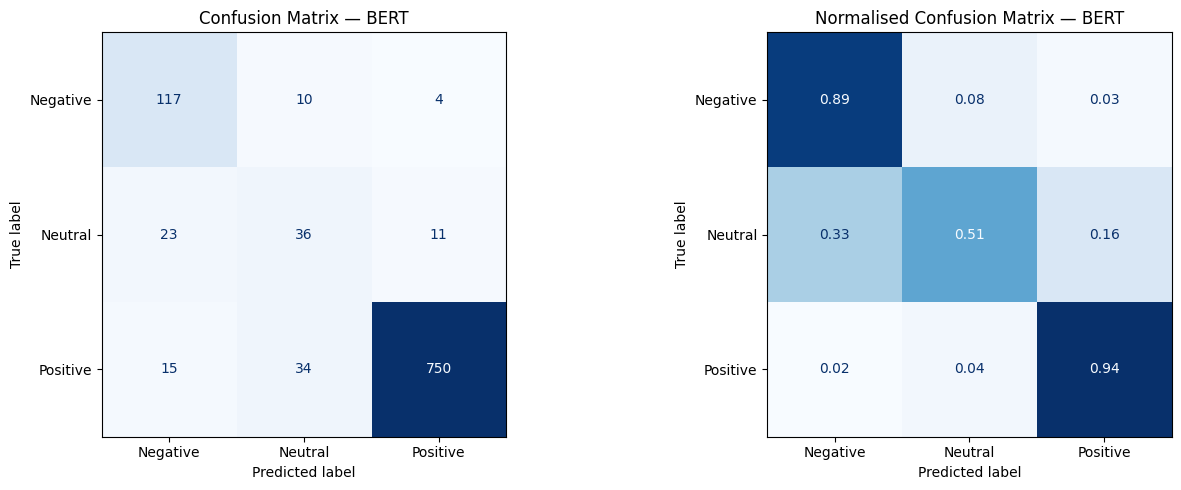

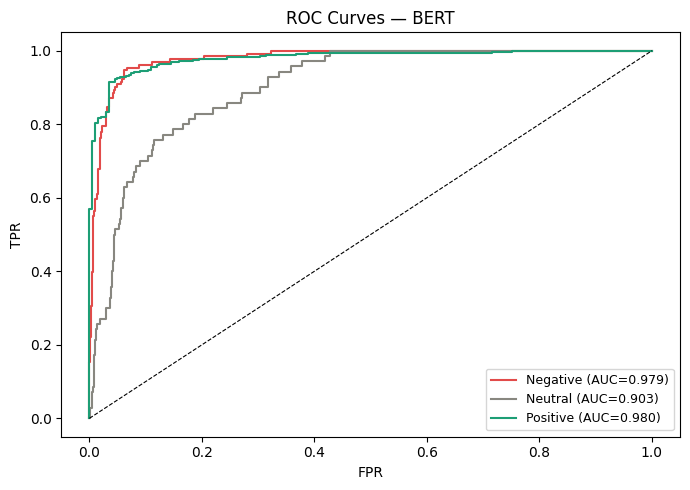

In [21]:
# ── 5.14  CONFUSION MATRIX & ROC ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test_arr, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — BERT')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('Normalised Confusion Matrix — BERT')
plt.tight_layout()
plt.savefig('../results/05_bert_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

y_bin = label_binarize(y_test_arr, classes=[0,1,2])
fig, ax = plt.subplots(figsize=(7,5))
for i, (name, col) in enumerate(zip(CLASS_NAMES,['#E24B4A','#888780','#1D9E75'])):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba[:,i])
    ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_title('ROC Curves — BERT'); ax.legend(loc='lower right', fontsize=9)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
plt.tight_layout()
plt.savefig('../results/05_bert_roc.png', dpi=150, bbox_inches='tight')
plt.show()